# Figure 2 - tomography benchmark

This notebook regenerates the quantitative benchmark panels in main-text Figure 2 (panels c-h). The plotted modal fidelities are reconstructed from the optimized heater powers, the independently measured mixture-tomography eigenvectors, and the minimal heater calibration included with the repository. Visibility error bars denote one standard deviation propagated from the full covariance of each sinusoidal interferogram fit.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root() -> Path:
    """Find the repository whether Jupyter starts here or in notebooks/."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


ROOT = find_repo_root()
PNG_DIR = ROOT / "figures" / "png"
SVG_DIR = ROOT / "figures" / "svg"
PNG_DIR.mkdir(parents=True, exist_ok=True)
SVG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    """Save matching raster and vector copies of a figure."""
    fig.savefig(PNG_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(SVG_DIR / f"{filename}.svg", bbox_inches="tight")

# Final dimensions are appropriate for a full-width, two-column figure.
FULL_PAGE_WIDTH_IN = 7.1
FONT_SIZE_PT = 7

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": FONT_SIZE_PT,
    "axes.labelsize": FONT_SIZE_PT,
    "axes.titlesize": FONT_SIZE_PT,
    "xtick.labelsize": FONT_SIZE_PT,
    "ytick.labelsize": FONT_SIZE_PT,
    "legend.fontsize": FONT_SIZE_PT,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
from dataclasses import dataclass
from scipy.optimize import curve_fit


## Load the benchmark and minimal calibration

In [2]:
DATA_FILE = ROOT / "data" / "figure2" / "tomo_benchmark_2025-12-19_23-23-33.npy"
CALIBRATION_FILE = ROOT / "data" / "figure2" / "heater_calibration.csv"

data = np.load(DATA_FILE, allow_pickle=True).item()
rows = np.genfromtxt(CALIBRATION_FILE, delimiter=",", names=True)
calibration = {
    int(row["channel"]): (float(row["v_bar"]), float(row["v_cross"]))
    for row in np.atleast_1d(rows)
}

# Theta heaters tune the beamsplitter ratio; all remaining listed heaters tune phi.
theta_channels = {34, 36, 5, 10, 14, 18, 22, 26, 29, 31, 30, 32, 28, 25, 21, 17, 13, 9, 6}
VOLTS_TO_RADIANS = 0.092
print(f"Loaded calibration for {len(calibration)} phase shifters.")

Loaded calibration for 10 phase shifters.


## Convert heater powers into the learned optical modes

In [3]:
def angle_from_power(channel, power):
    """Map electrical heater power to optical phase using bar/cross states."""
    v_bar, v_cross = calibration[channel]
    return ((power - v_cross**2) * np.pi / (v_bar**2 - v_cross**2)) % (2 * np.pi)


def one_mzi(size, index, theta, phi, kappa=np.pi / 4, alpha=0.0):
    """Unitary matrix of one calibrated 2x2 interferometer embedded in a layer."""
    a = np.exp(1j * phi) * (np.cos(2 * kappa) * np.cos(theta / 2) + 1j * np.sin(theta / 2))
    b = np.exp(1j * alpha) * np.sin(2 * kappa) * np.cos(theta / 2)
    c = -np.exp(1j * (phi - alpha)) * np.sin(2 * kappa) * np.cos(theta / 2)
    d = np.cos(2 * kappa) * np.cos(theta / 2) - 1j * np.sin(theta / 2)
    block = np.exp(1j * theta / 2) * np.array([[a, b], [c, d]])
    matrix = np.eye(size, dtype=complex)
    matrix[index:index + 2, index:index + 2] = block
    return matrix


def one_layer(size, thetas, phis):
    matrix = np.eye(size, dtype=complex)
    for index in range(size - 1):
        matrix = matrix @ one_mzi(size, index, thetas[index], phis[index])
    return matrix


def learned_mode_fidelity(channels, powers, tomography_basis):
    theta, phi = [], []
    for channel, power in zip(channels, powers):
        phase = angle_from_power(channel, power)
        (theta if channel in theta_channels else phi).append(phase)
    mesh = one_layer(len(theta) + 1, theta[::-1], phi[::-1])
    return np.abs((mesh @ tomography_basis)[0, 0])


def mixture_eigendecomposition(sequential, refined):
    suffix = "_refined" if refined else ""
    u1 = np.asarray(sequential[f"u1{suffix}"])
    u2 = np.asarray(sequential[f"u2{suffix}"])
    n1 = sequential[0][f"final_intensity{suffix}"]
    n2 = sequential[1][f"final_intensity{suffix}"]
    rho = n1 * np.outer(u1, np.conj(u1)) + n2 * np.outer(u2, np.conj(u2))
    eigenvalues, eigenvectors = np.linalg.eigh(rho)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]


eigenvalues_1, basis_1 = mixture_eigendecomposition(
    data["tomography"]["sequential_tomography"], refined=True
)
eigenvalues_2, basis_2 = mixture_eigendecomposition(
    data["tomography_2"]["sequential_tomography"], refined=False
)

layer_1 = data["optimization_layer_1"]["layer1"]
layer_2 = data["optimization_layer_2"]["layer2"]
channels_1 = [35, 34, 42, 36, 4, 5]
channels_2 = [43, 6, 8, 9]

fidelity_1 = np.array([
    learned_mode_fidelity(channels_1, step[0][0], basis_1) for step in layer_1["history"]
])
fidelity_2 = np.array([
    learned_mode_fidelity(channels_2, step[0][0], basis_2) for step in layer_2["history"]
])

print(f"Final fidelities: layer 1 = {fidelity_1[-1]:.4f}, layer 2 = {fidelity_2[-1]:.4f}")

Final fidelities: layer 1 = 0.9784, layer 2 = 0.9993


## Fit the residual two-mode interferograms

In [4]:
def sine_model(x, amplitude, frequency, phase, offset):
    return amplitude * np.sin(frequency * x + phase) + offset


def initial_sine_guess(x, y):
    order = np.argsort(x)
    x, y = np.asarray(x)[order], np.asarray(y)[order]
    offset = np.mean(y)
    centered = y - offset
    amplitude = max(0.5 * np.ptp(y), np.std(centered), 1e-12)
    spacing = np.median(np.diff(x))
    spectrum = np.fft.rfft(centered)
    frequencies = np.fft.rfftfreq(len(x), d=spacing)
    peak = np.argmax(np.abs(spectrum[1:])) + 1
    return amplitude, 2 * np.pi * frequencies[peak], 0.0, offset


def fitted_visibility(x, y):
    """Return visibility and its 1-sigma fit uncertainty.

    For A sin(wx+phi)+C, visibility is |A|/C. Its uncertainty is
    propagated from the full fit covariance, including covariance between
    the fitted amplitude and offset.
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    parameters, covariance = curve_fit(
        sine_model, x, y, p0=initial_sine_guess(x, y), maxfev=50_000
    )
    amplitude, _, _, offset = parameters
    visibility = abs(amplitude) / offset

    # Gradient of |A|/C with respect to [A, frequency, phase, C].
    gradient = np.zeros(4, dtype=float)
    gradient[0] = np.sign(amplitude) / offset
    gradient[3] = -abs(amplitude) / offset**2
    variance = float(gradient @ covariance @ gradient)
    uncertainty = np.sqrt(max(variance, 0.0))
    return visibility, uncertainty


def visibility_history(layer):
    fitted = np.array([
        fitted_visibility(x, y)
        for x, y in zip(layer["contrast_all_history_x"], layer["contrast_all_history_y"])
    ])
    return fitted[:, 0], fitted[:, 1]


visibility_1, visibility_error_1 = visibility_history(layer_1)
visibility_2, visibility_error_2 = visibility_history(layer_2)
visibility_epochs_1 = np.arange(len(visibility_1)) * (len(fidelity_1) // len(visibility_1))
visibility_epochs_2 = np.arange(len(visibility_2)) * (len(fidelity_2) // len(visibility_2))
print(
    "Final fitted visibilities: "
    f"{visibility_1[-1]:.3f} +/- {visibility_error_1[-1]:.3f}, "
    f"{visibility_2[-1]:.3f} +/- {visibility_error_2[-1]:.3f}"
)

Final fitted visibilities: 0.123 +/- 0.001, 0.101 +/- 0.003


## Plot panels c-h

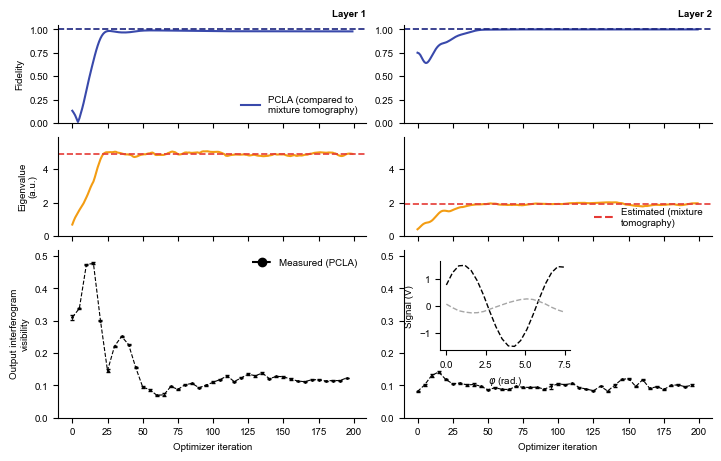

In [5]:
fig, axes = plt.subplots(
    3, 2, figsize=(FULL_PAGE_WIDTH_IN, 4.5), sharex=True,
    gridspec_kw={"height_ratios": [0.85, 0.85, 1.45]},
    constrained_layout=True,
)

blue, dark_blue, orange, red = "#3949ab", "#1a237e", "#f39c12", "#e53935"
fidelities = (fidelity_1, fidelity_2)
layers = (layer_1, layer_2)
eigenvalues = (eigenvalues_1[0], eigenvalues_2[0])
visibilities = (visibility_1, visibility_2)
visibility_errors = (visibility_error_1, visibility_error_2)
visibility_epochs = (visibility_epochs_1, visibility_epochs_2)

for column in range(2):
    fidelity = fidelities[column]
    layer = layers[column]
    eigenvalue = eigenvalues[column]

    axes[0, column].plot(fidelity, color=blue, linewidth=1.5)
    axes[0, column].axhline(1.0, color=dark_blue, linestyle="--", linewidth=1.2)
    axes[0, column].set_ylim(0, 1.05)
    axes[0, column].set_title(f"Layer {column + 1}", loc="right", fontweight="bold")

    axes[1, column].plot(layer["history_lockin"], color=orange, linewidth=1.5)
    axes[1, column].axhline(eigenvalue, color=red, linestyle="--", linewidth=1.2)
    axes[1, column].set_ylim(0, eigenvalues[0] + 1)

    axes[2, column].errorbar(
        visibility_epochs[column], visibilities[column],
        yerr=visibility_errors[column], fmt="o--",
        color="black", markersize=1.0, linewidth=0.8,
        elinewidth=0.6, capsize=1.5,
    )
    axes[2, column].set_ylim(0, 0.52)
    axes[2, column].set_xlabel("Optimizer iteration")

axes[0, 0].set_ylabel("Fidelity")
axes[1, 0].set_ylabel("Eigenvalue\n(a.u.)")
axes[2, 0].set_ylabel("Output interferogram\nvisibility")

axes[0, 0].plot([], [], color=blue, label="PCLA (compared to\nmixture tomography)")
axes[0, 0].legend(frameon=False, loc="lower right")
axes[1, 1].plot([], [], color=red, linestyle="--", label="Estimated (mixture\ntomography)")
axes[1, 1].legend(frameon=False, loc="lower right")
axes[2, 0].plot([], [], "o--", color="black", label="Measured (PCLA)")
axes[2, 0].legend(frameon=False, loc="upper right")

# The small inset in the publication shows representative high- and
# low-visibility raw fringes used by the fitting routine above.
inset = axes[2, 1].inset_axes([0.12, 0.40, 0.42, 0.53])
for index, color in ((2, "black"), (12, "0.65")):
    x = np.asarray(layer_1["contrast_all_history_x"][index]) * VOLTS_TO_RADIANS
    y = np.asarray(layer_1["contrast_all_history_y"][index])
    y = y - 0.5 * (np.max(y) + np.min(y))
    inset.plot(x, y, "--", color=color, linewidth=1.0)
inset.set_xlabel(r"$\varphi$ (rad.)", fontsize=FONT_SIZE_PT)
inset.set_ylabel("Signal (V)", fontsize=FONT_SIZE_PT)
inset.tick_params(labelsize=FONT_SIZE_PT)

save_figure(fig, "figure2_benchmark_panels")
plt.show()